In [ ]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
###Importo las hojas correspondientes del archivo travel
data = pd.read_excel("/content/drive/MyDrive/Analitica de los negocios/2.2 Travel_Plan_Data Ultima .xlsx", sheet_name=0)
score = pd.read_excel("/content/drive/MyDrive/Analitica de los negocios/2.2 Travel_Plan_Data Ultima .xlsx", sheet_name=1)

2. Depuro datos




In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   College     200 non-null    int64  
 1   CreditCard  200 non-null    int64  
 2   FoodSpend   200 non-null    float64
 3   Income      200 non-null    int64  
 4   TravelPlan  200 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 7.9 KB


In [ ]:
score.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   College     2 non-null      int64  
 1   CreditCard  2 non-null      int64  
 2   FoodSpend   2 non-null      float64
 3   Income      2 non-null      int64  
dtypes: float64(1), int64(3)
memory usage: 196.0 bytes


In [ ]:
data

,College,CreditCard,FoodSpend,Income,TravelPlan
0,0,0,2905.97,65982,1
1,1,0,4677.03,57274,1
2,0,0,5068.53,58520,1
3,0,1,4252.09,47330,0
4,0,0,6438.27,54422,1
...,...,...,...,...,...
195,0,1,3405.75,46050,0
196,0,0,2892.90,65982,1
197,0,0,9129.66,59676,1
198,1,1,5550.56,47806,0


In [ ]:
score

,College,CreditCard,FoodSpend,Income
0,0,1,2892.90,65982
1,1,0,6017.66,53986


3. Split de datos

In [ ]:
XD = data[["College", "CreditCard", "FoodSpend", "Income"]] ## Variables independientes
yd = data[["TravelPlan"]] ## Variable dependiente (la que vamos a predecir)

###4. IMPORTAR MODELO DEL ARBOL DE DECISION

In [ ]:
## Importo las librerías necesarias
import pandas as pd, numpy as np, matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix


In [ ]:
## Creo la variable que aloja al modelo
DTModel = DecisionTreeClassifier(criterion="gini" , max_depth=4)

In [ ]:
## ENTRENO el modelo
DTModel.fit(XD, yd)

DecisionTreeClassifier(max_depth=4)

In [ ]:
## Genero las predicciones
DTModel.predict(XD)

array([0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 0])

In [ ]:
## Genero las predicciones
ydPred = DTModel.predict(XD)

##5 - METRICAS DE CONSTRUCCION DEL MODELO

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
cm = confusion_matrix(yd, ydPred)
cm

array([[105,  16],
       [ 31,  48]])

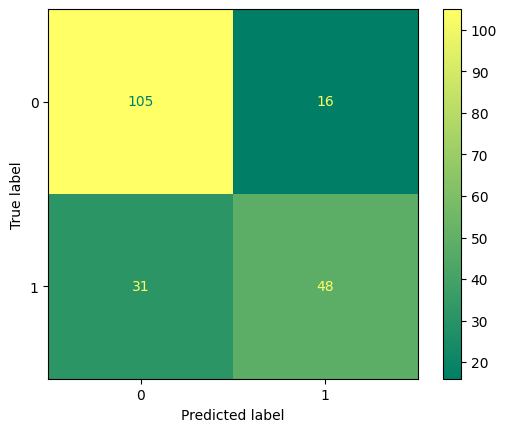

In [ ]:
import matplotlib.pyplot as plt
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=DTModel.classes_)

disp.plot(cmap="summer")
plt.show()

In [ ]:
from re import S
# METRICAS DE EVALUACION

# Extraigo los valores de la matriz de confusión
VN=cm[0,0]; FP=cm[0,1]; FN=cm[1,0]; VP=cm[1,1]

# METRICAS
# Exactitud (Acurracy)
exactitud=(VN+VP)/cm.sum()
print(f"La exactitud (accuracy) del modelo es de {exactitud:.2%}")

# Tasas de error
error = 1-exactitud
print(f"El error del modelo es de {error:.2%}")

# Precisión
presicion = VP/(VP+FP)
print(f"La precisión del modelo es de {presicion:.2%}")

# Sensibilidad
sensibilidad = VP/(VP+FN)
print(f"La sensibilidad del modelo es de {sensibilidad:.2%}")

# Especificidad
especificidad = VN/(VN+FP)
print(f"La especificidad del modelo es de {especificidad:.2%}")

La exactitud (accuracy) del modelo es de 76.50%
El error del modelo es de 23.50%
La precisión del modelo es de 75.00%
La sensibilidad del modelo es de 60.76%
La especificidad del modelo es de 86.78%


###6. Pronostico para nuevos clientes

In [ ]:
## Generalizo el modelo con los datos de score (son datos no conocidos previamente por el modelo)
ydGener = DTModel.predict(score)


In [ ]:
ydGener

array([0, 0])

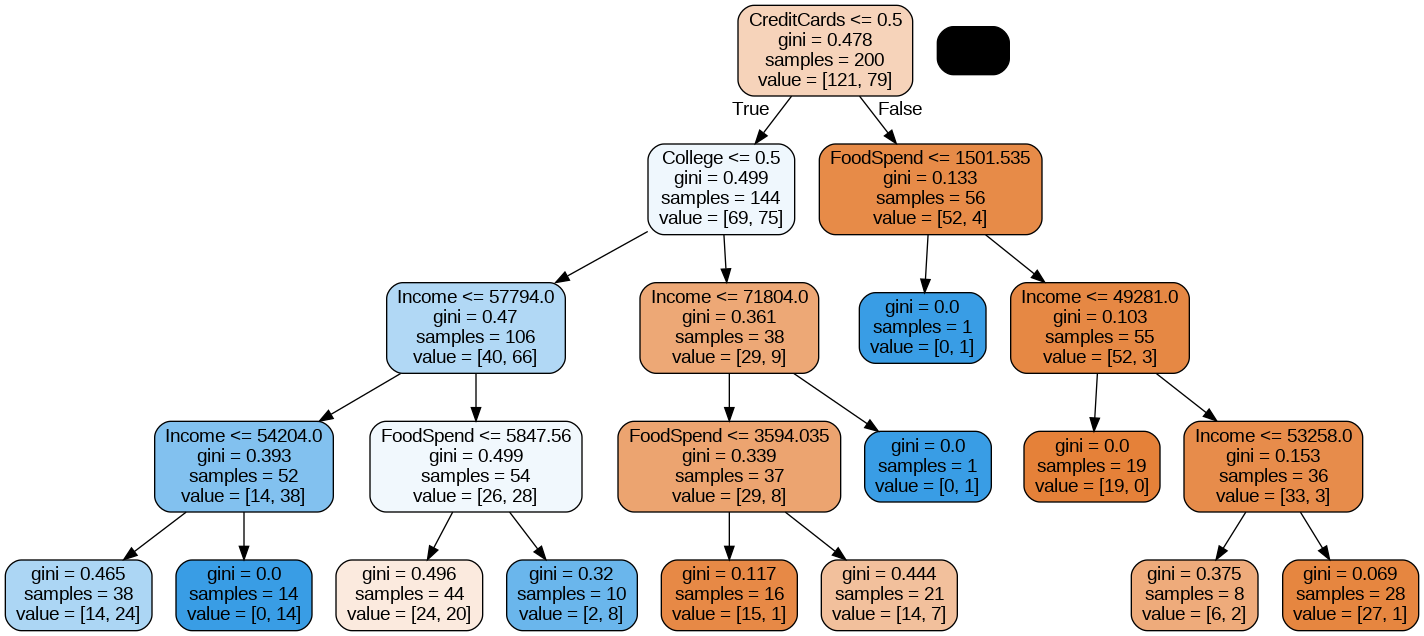

In [91]:
from sklearn.tree import export_graphviz
from pydotplus import graph_from_dot_data
from IPython.display import Image
from six import StringIO
import pydotplus

vars = ["College", "CreditCards", "FoodSpend", "Income"]
dot_data =  StringIO()

export_graphviz(DTModel, out_file=dot_data, feature_names=vars, filled=True, rounded=True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

In [ ]:
####¿Cual es la probabilidad de que el primer cliente tenga planes de viajar en un año ?
primerCliente=1/28

####¿Cuál es la probabilidad de que el segundo cliente tenga planes de viajar el próximo año:?
segundoCliente = 7/21

NODOS PUROS

Las reglas de los nodos puros son:

(Si)IF CreditCard<=0.5 AND College<=0.5 AND Income<=57794.0 AND Income>54204.0

(Si)IF CreditCard<=0.5 AND College>0.5 AND Income>71804.0

(Si)IF CreditCard>0.5 AND FoodSpend<=1501.535

(Si)IF CreditCard>0.5 AND FoodSpend>1501.535 AND Income<=49281.0

REGLAS PARA EL 1ER Y 2DO CLIENTE

Primer Cliente: IF CreditCard>0.5 AND FoodSpend>1501.53 AND Income>53258.0

Segundo Cliente: IF CreditCard<=0.5 AND College>0.5 AND Income<=71804.0 AND FoodSpend>3594.035

ANALISIS GENERAL CLIENTES

Podemmos ver gracias a la reglas dadas para el 1er y para el 2do cliente como estos tienen ciertas caracteristicas a cumplir. Por ejemplo:

El 1er cliente tiene una tarjeta de credito o es muy probable tenga un alto puntaje en esta. Ademas este cuenta con un gasto en comida mayor a 1501.35. Por ultimo este cuenta con ingresos mayores a 53258.

El 2do cliente probablemente no use tarjeta de credito (o su puntaje es bajo) y tiene ingresos no superiores a 71804.